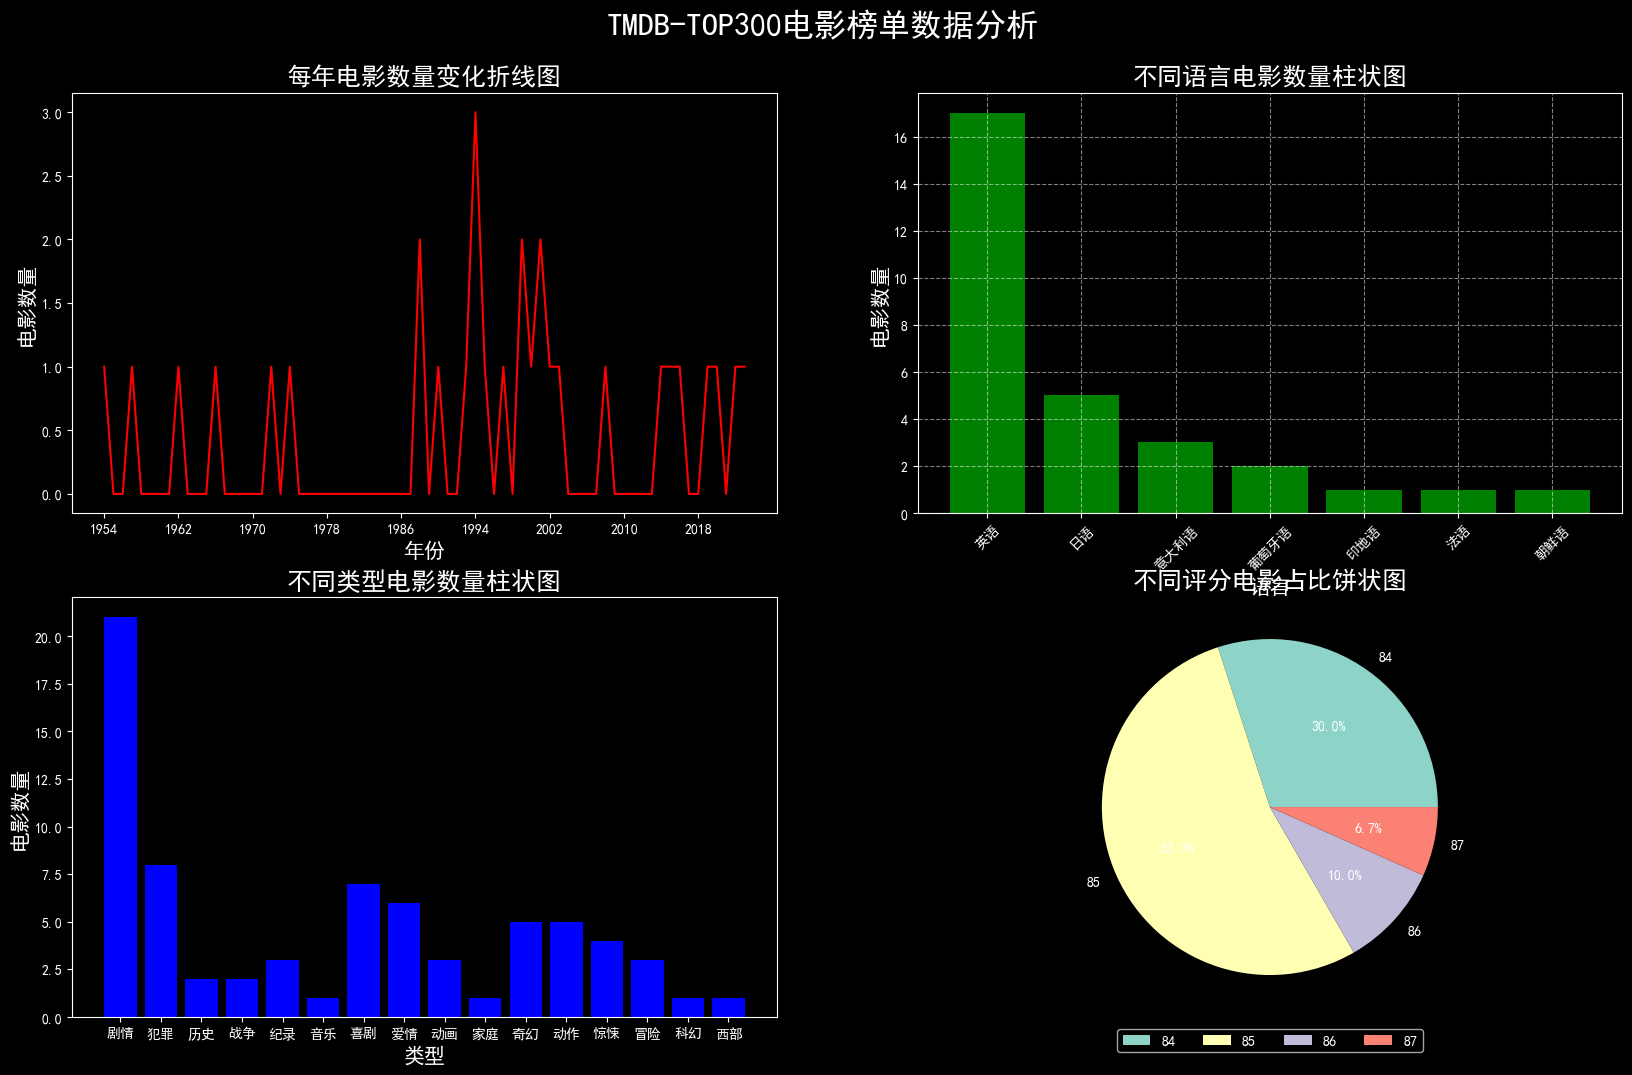

In [8]:
import pandas as pd
import matplotlib.pyplot as plt


# 展示中文
plt.rcParams['font.sans-serif'] = ['SimHei']

#创建子图
fig,axes = plt.subplots(nrows=2,ncols=2,figsize = (20,12),dpi = 100)
fig.suptitle('TMDB-TOP300电影榜单数据分析',fontsize = 23,x=0.5,y=0.95)

# 获取子图
axes1 = axes[0,0]
axes2 = axes[0,1]
axes3 = axes[1,0]
axes4 = axes[1,1]

# 加载数据
data = pd.read_csv('data/movies.csv',nrows=30,usecols=['电影名','年份','上映时间','类型','时长','评分','语言'],dtype={'年份':"Int64"})
data

# 统计top300的电影中，每一年上映的电影数量的变化。折线图
# 缺失值异常值处理
data['年份'] = data['年份'].fillna(data['上映时间'].str[:4])

# 分组统计
year_count = data.groupby('年份')['年份'].count()

# 组装数据
min_year = year_count.index.min()
max_year = year_count.index.max()
x = [i for i in range(min_year,max_year+1)]

# y轴数据
y = [int(year_count.get(i,0)) for i in x]

# 绘制折线图
axes1.plot(x,y,color = 'red')
axes1.set_title('每年电影数量变化折线图',fontsize = 18)
axes1.set_xlabel('年份',fontsize = 15)
axes1.set_ylabel('电影数量',fontsize = 15)
axes1.set_xticks(x[::8])

# 需求二:统计对比不同语言的电影数量
language_count = data.groupby('语言')['语言'].count().sort_values(ascending=False)

x_language = language_count.index.tolist()
y_language_count = language_count.values.tolist()

# 绘制柱状图
axes2.bar(x_language,y_language_count,color = 'green')
axes2.set_title('不同语言电影数量柱状图',fontsize = 18)
axes2.set_xlabel('语言',fontsize = 15)
axes2.set_ylabel('电影数量',fontsize = 15)
# 添加网格线
axes2.grid(linestyle='--',alpha=0.5)
axes2.tick_params(axis='x',labelrotation=45)


# 需求三:统计不同类型电影数量
type_count = {}
for types in data['类型'].str.split(','):
    for type in types:
        if type in type_count:
            type_count[type] += 1
        else:
            type_count[type] = 1

x_types = list(type_count.keys())
y_values = list(type_count.values())


# 绘制柱状图
axes3.bar(x_types,y_values,color = 'blue')
axes3.set_title('不同类型电影数量柱状图',fontsize = 18)
axes3.set_xlabel('类型',fontsize = 15)
axes3.set_ylabel('电影数量',fontsize = 15)

# 需求四:统计不同评分电影占比(饼状图)
score_count = data.groupby('评分')['评分'].count()
# 合并小数据(比率小于2%)
total = score_count.sum()
large_scores = score_count.loc[score_count >= total*0.02] # 大数据 比例大于2%
small_scores = score_count.loc[score_count < total*0.02] # 小数据 比例小于2%

if small_scores.shape[0] > 0:
    large_scores['其他'] = small_scores.sum()

scores = large_scores.index.tolist()
values = large_scores.values.tolist()

axes4.pie(values,labels=scores,autopct='%1.1f%%',startangle=0)
axes4.set_title('不同评分电影占比饼状图',fontsize = 18)
axes4.legend(loc='lower center',ncol = 4,bbox_to_anchor=(0.5,-0.1))

plt.show()
